# EDA — ObRail Europe : Substitution Avion → Train

**Enjeu :** Identification automatique des lignes candidates à la substitution avion par train  
**Source :** `donnee/staging_fact_route_analysis.csv` — 1509 corridors uniques après nettoyage  
**Référence CO2 :** Méthodologie EcoPassenger (UIC/IFEU 2016)  
**Label :** `is_substitutable = 1` si distance ≤ 600 km ET vol existant (loi française 2023)

## 0. Imports et chargement

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings

    
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

# Chargement du fichier source ML
df = pd.read_csv('../donnee/staging_fact_route_analysis.csv')
print(f'Dataset : {len(df)} lignes, {len(df.columns)} colonnes')
df.head()

Dataset : 1509 lignes, 13 colonnes


,origin,destination,vehicule_type,co2_train_kg,co2_avion_kg,co2_saved_kg,is_substitutable,traffic_share_pct,distance_km,station_lat,station_long,station_lat_dest,station_long_dest
0,"Aalen, Hauptbahnhof",Aulendorf Bahnhof,Train Longue Distance Nuit,1.655983,NaN,NaN,0,NaN,104.307324,48.841678,10.096129,47.952968,9.643900
1,"Aalen, Hauptbahnhof",Bahnhof Überlingen,Train Longue Distance Nuit,2.187761,86.415084,84.227324,1,NaN,137.803012,48.841678,10.096129,47.768968,9.163058
2,"Aalen, Hauptbahnhof",Friedrichshafen Stadtbahnhof,Train Longue Distance Nuit,2.221879,80.218703,77.996824,1,NaN,139.952077,48.841678,10.096129,47.653282,9.473570
3,"Aalen, Hauptbahnhof",Ludwigshafen(Bodensee) Bahnhof,Train Longue Distance Nuit,2.186171,83.104731,80.918560,1,NaN,137.702878,48.841678,10.096129,47.815601,9.053149
4,"Aalen, Hauptbahnhof",Radolfzell Bahnhof,Train Longue Distance Nuit,2.358583,83.104731,80.746148,1,NaN,148.562788,48.841678,10.096129,47.735852,8.969157


## 1. Vue d'ensemble du dataset

In [10]:
print('=== Types et valeurs manquantes ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(1)
})
print(info.to_string())

=== Types et valeurs manquantes ===
                     dtype  non_null  null  null_%
origin              object      1509     0     0.0
destination         object      1509     0     0.0
vehicule_type       object      1509     0     0.0
co2_train_kg       float64      1509     0     0.0
co2_avion_kg       float64      1377   132     8.7
co2_saved_kg       float64      1377   132     8.7
is_substitutable     int64      1509     0     0.0
traffic_share_pct  float64         0  1509   100.0
distance_km        float64      1509     0     0.0
station_lat        float64      1509     0     0.0
station_long       float64      1509     0     0.0
station_lat_dest   float64      1509     0     0.0
station_long_dest  float64      1509     0     0.0


In [11]:
print('=== Stats descriptives ===')
df[['distance_km','co2_train_kg','co2_avion_kg','co2_saved_kg']].describe().round(2)

=== Stats descriptives ===


,distance_km,co2_train_kg,co2_avion_kg,co2_saved_kg
count,1509.00,1509.00,1377.00,1377.00
mean,191.69,4.35,94.21,89.57
std,160.18,9.88,29.14,22.38
min,100.10,0.09,64.20,58.45
25%,113.27,0.86,76.82,75.22
50%,132.15,1.33,85.45,84.31
75%,173.35,2.09,100.05,97.98
max,1154.26,89.59,240.82,235.39


## 2. Distribution de la cible : `is_substitutable`

⚠️ Déséquilibre de classe à prendre en compte dans l'entraînement (`class_weight='balanced'`)

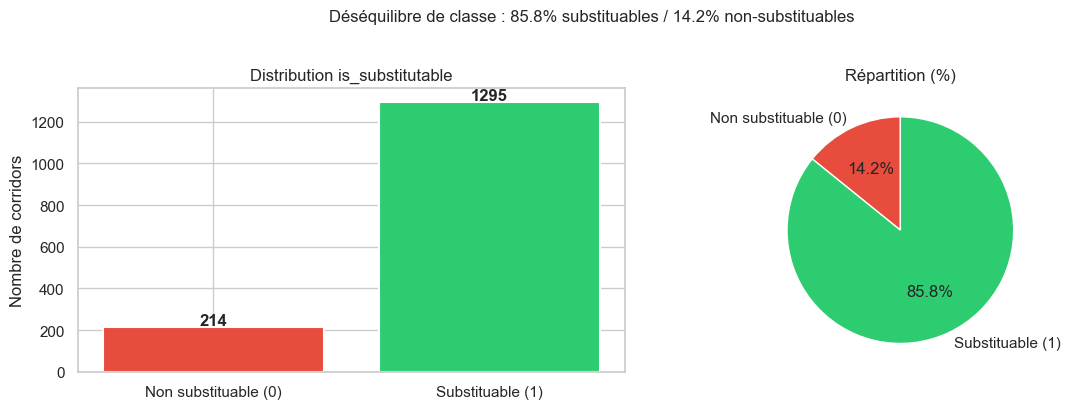

Ratio : 85.8% substituables (1295) / 14.2% non-substituables (214)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Comptage
counts = df['is_substitutable'].value_counts()
labels = ['Non substituable (0)', 'Substituable (1)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, [counts[0], counts[1]], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution is_substitutable')
axes[0].set_ylabel('Nombre de corridors')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Camembert
axes[1].pie([counts[0], counts[1]], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition (%)')

plt.suptitle('Déséquilibre de classe : 85.8% substituables / 14.2% non-substituables',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../docs/fig_is_substitutable.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Ratio : {counts[1]/len(df)*100:.1f}% substituables ({counts[1]}) / {counts[0]/len(df)*100:.1f}% non-substituables ({counts[0]})')

## 3. Distributions des features numériques

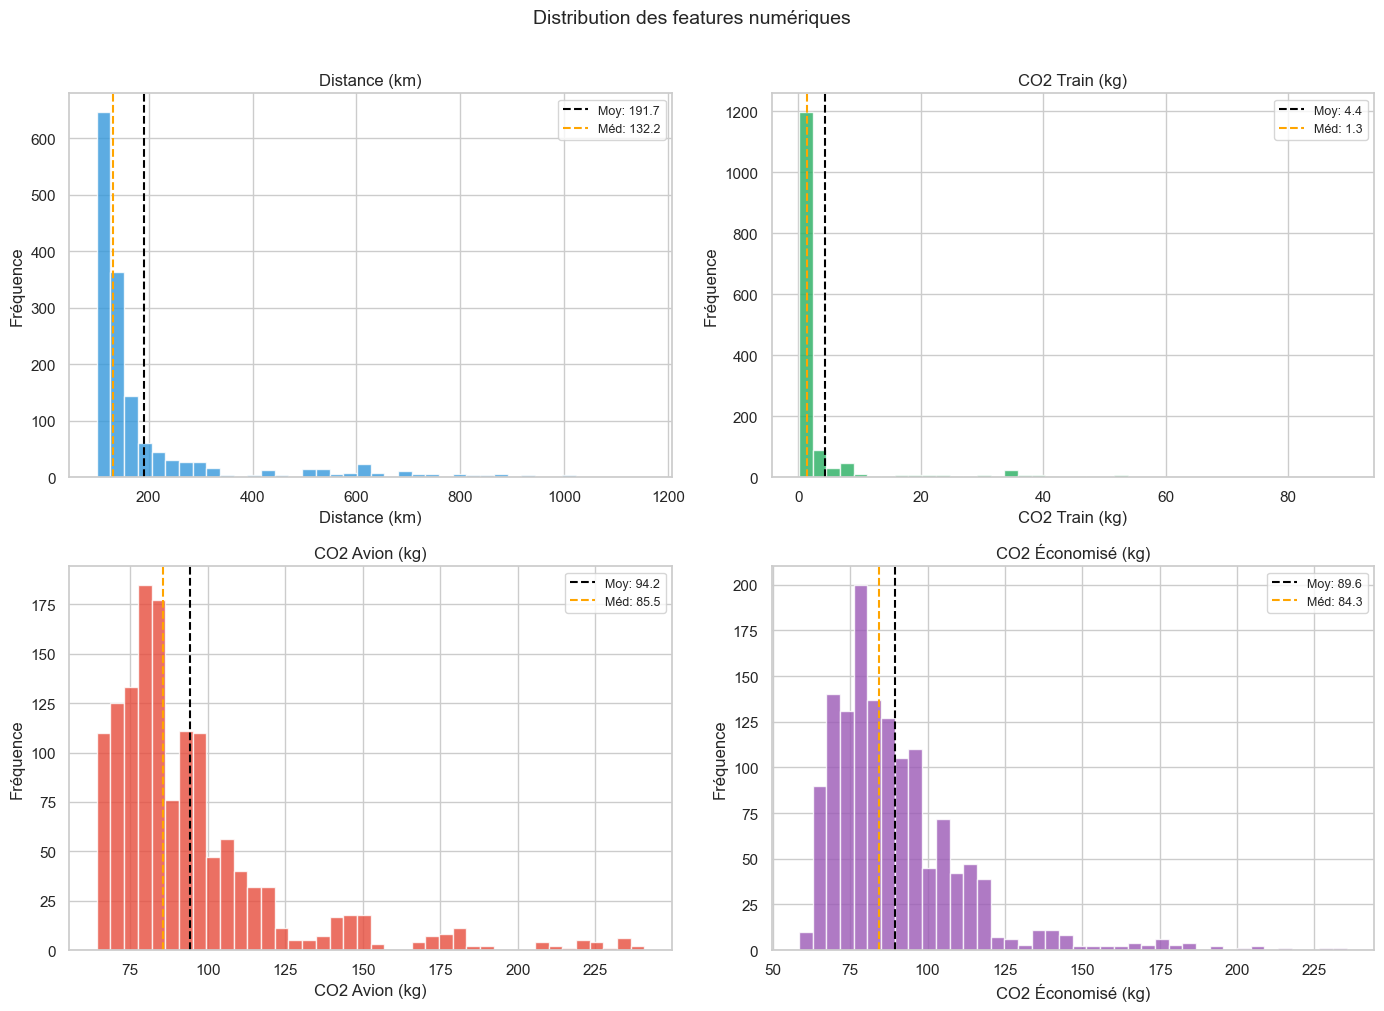

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = [
    ('distance_km',   'Distance (km)',      '#3498db'),
    ('co2_train_kg',  'CO2 Train (kg)',     '#27ae60'),
    ('co2_avion_kg',  'CO2 Avion (kg)',     '#e74c3c'),
    ('co2_saved_kg',  'CO2 Économisé (kg)', '#9b59b6'),
]

for ax, (col, label, color) in zip(axes.flatten(), features):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Moy: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Méd: {data.median():.1f}')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=9)

plt.suptitle('Distribution des features numériques', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../docs/fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. CO2 Train vs Avion par corridor (comparaison)

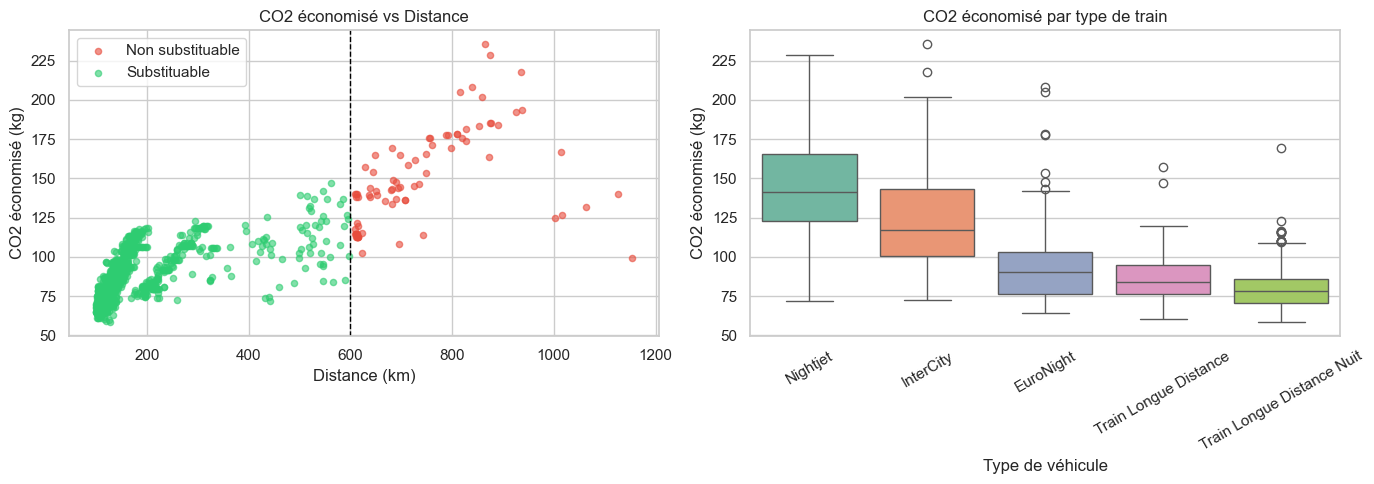

Gain CO2 moyen train vs avion : 89.6 kg/passager
Facteur multiplicateur CO2 avion/train : x73


In [6]:
df_both = df.dropna(subset=['co2_avion_kg'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter CO2 train vs avion
colors_map = {1: '#2ecc71', 0: '#e74c3c'}
for val, grp in df_both.groupby('is_substitutable'):
    label = 'Substituable' if val == 1 else 'Non substituable'
    axes[0].scatter(grp['distance_km'], grp['co2_saved_kg'],
                   c=colors_map[val], label=label, alpha=0.6, s=20)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('CO2 économisé (kg)')
axes[0].set_title('CO2 économisé vs Distance')
axes[0].legend()
axes[0].axvline(600, color='black', linestyle='--', linewidth=1, label='Seuil 600km')

# Boxplot CO2 saved par type de véhicule
order = df_both.groupby('vehicule_type')['co2_saved_kg'].median().sort_values(ascending=False).index
sns.boxplot(data=df_both, x='vehicule_type', y='co2_saved_kg', order=order, ax=axes[1], palette='Set2')
axes[1].set_xlabel('Type de véhicule')
axes[1].set_ylabel('CO2 économisé (kg)')
axes[1].set_title('CO2 économisé par type de train')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../docs/fig_co2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gain CO2 moyen train vs avion : {df_both["co2_saved_kg"].mean():.1f} kg/passager')
print(f'Facteur multiplicateur CO2 avion/train : x{(df_both["co2_avion_kg"]/df_both["co2_train_kg"]).median():.0f}')

## 5. Distribution par type de véhicule

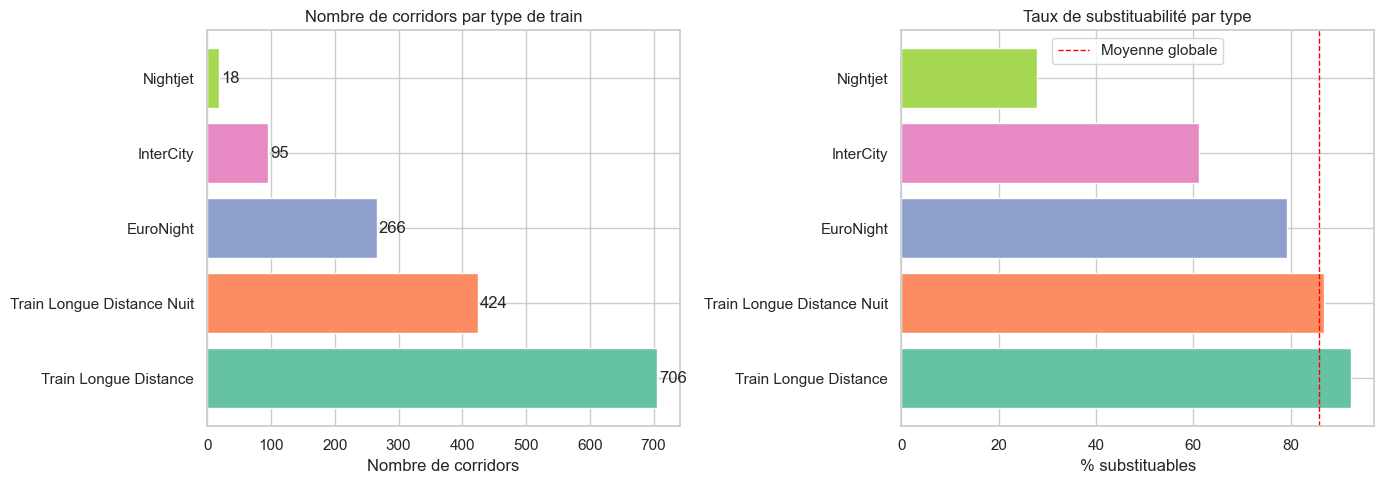

vehicule_type
Train Longue Distance         92.5%
Train Longue Distance Nuit    86.8%
EuroNight                     79.3%
InterCity                     61.1%
Nightjet                      27.8%
Name: is_substitutable, dtype: object


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comptage par type
vt_counts = df['vehicule_type'].value_counts()
axes[0].barh(vt_counts.index, vt_counts.values, color=sns.color_palette('Set2', len(vt_counts)))
axes[0].set_title('Nombre de corridors par type de train')
axes[0].set_xlabel('Nombre de corridors')
for i, v in enumerate(vt_counts.values):
    axes[0].text(v + 3, i, str(v), va='center')

# Taux de substituabilité par type
sub_rate = df.groupby('vehicule_type')['is_substitutable'].mean().sort_values(ascending=False)
axes[1].barh(sub_rate.index, sub_rate.values * 100, color=sns.color_palette('Set2', len(sub_rate)))
axes[1].set_title('Taux de substituabilité par type')
axes[1].set_xlabel('% substituables')
axes[1].axvline(85.8, color='red', linestyle='--', linewidth=1, label='Moyenne globale')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/fig_vehicule_type.png', dpi=150, bbox_inches='tight')
plt.show()
print(sub_rate.apply(lambda x: f'{x*100:.1f}%'))

## 6. Matrice de corrélations

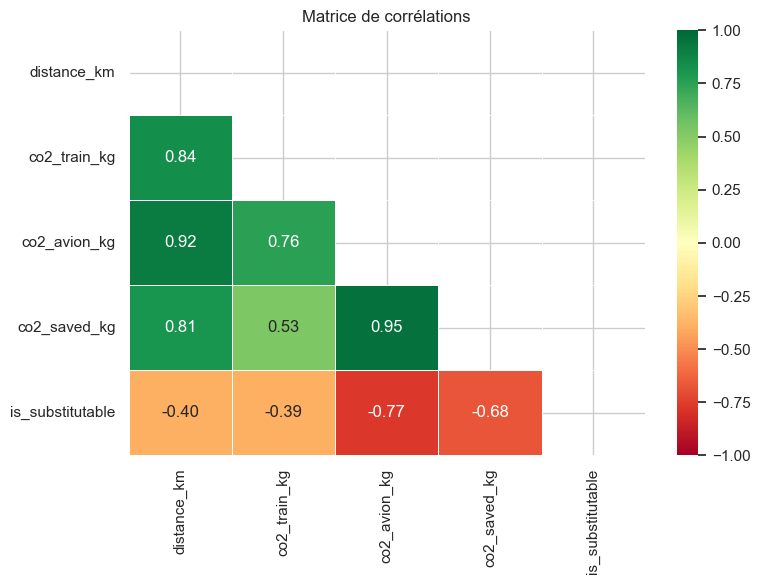

Corrélations avec is_substitutable :
co2_avion_kg   -0.773369
co2_saved_kg   -0.676014
distance_km    -0.398126
co2_train_kg   -0.393019
Name: is_substitutable, dtype: float64


In [8]:
num_cols = ['distance_km', 'co2_train_kg', 'co2_avion_kg', 'co2_saved_kg', 'is_substitutable']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélations')
plt.tight_layout()
plt.savefig('../docs/fig_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Corrélations avec is_substitutable :')
print(corr['is_substitutable'].drop('is_substitutable').sort_values())

## 7. Valeurs manquantes

In [9]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
null_df = pd.DataFrame({'count': nulls, '%': nulls_pct}).query('count > 0')
print('Valeurs manquantes :')
print(null_df.to_string())
print()
print('→ traffic_share_pct : 100% NULL → colonne supprimée des features')
print('→ co2_avion_kg/co2_saved_kg : 132 lignes sans vol → exclues du Modèle 2 uniquement')

Valeurs manquantes :
                   count      %
co2_avion_kg         132    8.7
co2_saved_kg         132    8.7
traffic_share_pct   1509  100.0

→ traffic_share_pct : 100% NULL → colonne supprimée des features
→ co2_avion_kg/co2_saved_kg : 132 lignes sans vol → exclues du Modèle 2 uniquement


## 8. Tableau des variables retenues

Livrable explicite demandé par le sujet MSPR.

In [10]:
variables = pd.DataFrame([
    {'Variable':       'distance_km',
     'Type':          'Numérique',
     'Source':        'dim_route',
     'Rôle':          'Feature',
     'Justification': 'Corrélation forte avec substituabilité (seuil 600km loi FR)'},
    {'Variable':       'co2_train_kg',
     'Type':          'Numérique',
     'Source':        'fact',
     'Rôle':          'Feature / Target M2',
     'Justification': 'CO2 calculé EcoPassenger, varie selon pays (mix électrique)'},
    {'Variable':       'co2_avion_kg',
     'Type':          'Numérique',
     'Source':        'fact',
     'Rôle':          'Feature',
     'Justification': 'Présence = vol existant sur ce corridor (proxy aéroport proche)'},
    {'Variable':       'co2_saved_kg',
     'Type':          'Numérique',
     'Source':        'fact (calculé)',
     'Rôle':          'Target Modèle 2',
     'Justification': 'co2_avion - co2_train, aucun biais circulaire'},
    {'Variable':       'vehicule_type',
     'Type':          'Catégoriel',
     'Source':        'dim_vehicle_type',
     'Rôle':          'Feature',
     'Justification': 'TGV vs Train Nuit = profils CO2 très différents'},
    {'Variable':       'is_substitutable',
     'Type':          'Binaire (0/1)',
     'Source':        'fact (calculé)',
     'Rôle':          'Target Modèle 1',
     'Justification': 'Basé sur loi FR 2023 : distance ≤ 600km ET vol existant'},
    {'Variable':       'annual_station_traffic',
     'Type':          'Numérique',
     'Source':        'dim_station_frequentation',
     'Rôle':          'Feature (optionnelle)',
     'Justification': '46% couverture SNCF, proxy de la demande. NULL = 0 pour modèle'},
    {'Variable':       'city_population',
     'Type':          'Numérique',
     'Source':        'dim_station_frequentation',
     'Rôle':          'Feature (optionnelle)',
     'Justification': '68% couverture INSEE+GeoNames, densité de demande'},
    {'Variable':       'traffic_share_pct',
     'Type':          'Numérique',
     'Source':        'fact',
     'Rôle':          '❌ Supprimée',
     'Justification': '100% NULL, aucune donnée disponible'},
])

pd.set_option('display.max_colwidth', 80)
variables

,Variable,Type,Source,Rôle,Justification
0,distance_km,Numérique,dim_route,Feature,Corrélation forte avec substituabilité (seuil 600km loi FR)
1,co2_train_kg,Numérique,fact,Feature / Target M2,"CO2 calculé EcoPassenger, varie selon pays (mix électrique)"
2,co2_avion_kg,Numérique,fact,Feature,Présence = vol existant sur ce corridor (proxy aéroport proche)
3,co2_saved_kg,Numérique,fact (calculé),Target Modèle 2,"co2_avion - co2_train, aucun biais circulaire"
4,vehicule_type,Catégoriel,dim_vehicle_type,Feature,TGV vs Train Nuit = profils CO2 très différents
5,is_substitutable,Binaire (0/1),fact (calculé),Target Modèle 1,Basé sur loi FR 2023 : distance ≤ 600km ET vol existant
6,annual_station_traffic,Numérique,dim_station_frequentation,Feature (optionnelle),"46% couverture SNCF, proxy de la demande. NULL = 0 pour modèle"
7,city_population,Numérique,dim_station_frequentation,Feature (optionnelle),"68% couverture INSEE+GeoNames, densité de demande"
8,traffic_share_pct,Numérique,fact,❌ Supprimée,"100% NULL, aucune donnée disponible"


## 9. Visualisation géographique des corridors

folium non installé. Installer avec : pip install folium
Visualisation alternative avec matplotlib :


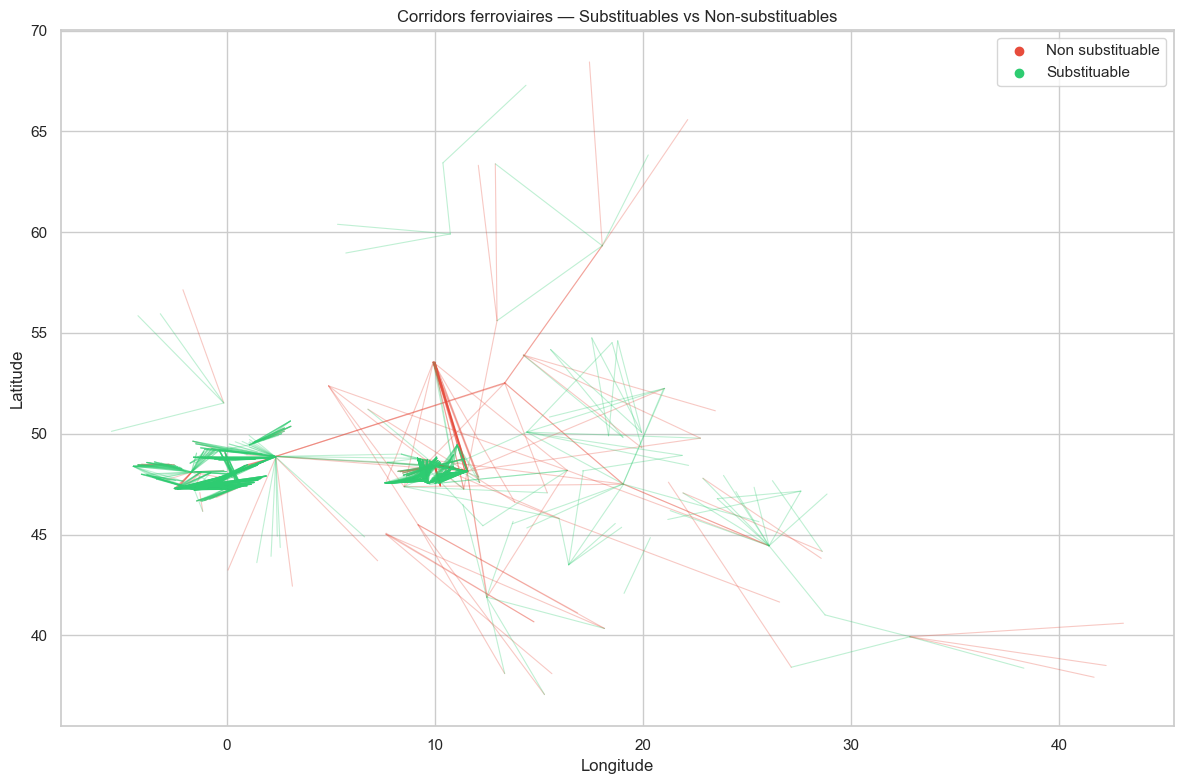

In [6]:
try:
    import folium
    
    m = folium.Map(location=[46.5, 2.5], zoom_start=5, tiles='CartoDB positron')
    
    df_geo = df.dropna(subset=['station_lat','station_long','station_lat_dest','station_long_dest'])
    
    for _, row in df_geo.iterrows():
        color = '#2ecc71' if row['is_substitutable'] == 1 else '#e74c3c'
        folium.PolyLine(
            locations=[
                [row['station_lat'], row['station_long']],
                [row['station_lat_dest'], row['station_long_dest']]
            ],
            color=color, weight=1.5, opacity=0.5,
            tooltip=f"{row['origin']} → {row['destination']} ({row['distance_km']:.0f}km, CO2 saved: {row.get('co2_saved_kg', 'N/A'):.1f}kg)"
        ).add_to(m)
    
    import os
    os.makedirs('../docs', exist_ok=True)
    m.save('../docs/carte_corridors.html')
    print('Carte sauvegardée : docs/carte_corridors.html')
    display(m)
    
except ImportError:
    print('folium non installé. Installer avec : pip install folium')
    print('Visualisation alternative avec matplotlib :')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    for val, grp in df.dropna(subset=['station_lat']).groupby('is_substitutable'):
        color = '#2ecc71' if val == 1 else '#e74c3c'
        label = 'Substituable' if val == 1 else 'Non substituable'
        for _, row in grp.iterrows():
            ax.plot([row['station_long'], row['station_long_dest']],
                    [row['station_lat'],  row['station_lat_dest']],
                    color=color, alpha=0.3, linewidth=0.8)
        ax.scatter([], [], color=color, label=label)
    ax.set_title('Corridors ferroviaires — Substituables vs Non-substituables')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../docs/fig_carte_corridors.png', dpi=150, bbox_inches='tight')
    plt.show()

## Synthèse EDA

| Point clé | Valeur | Impact ML |
|---|---|---|
| Taille dataset | 1509 corridors | Suffisant pour modèles simples |
| Déséquilibre classes | 85.8% / 14.2% | `class_weight='balanced'` obligatoire |
| Feature la plus corrélée | `distance_km` (-0.77 avec is_sub) | Feature principale Modèle 1 |
| Gain CO2 moyen | ~90 kg/passager | Signal fort pour Modèle 2 |
| `traffic_share_pct` | 100% NULL | Supprimée des features |
| `co2_avion_kg` manquant | 132 lignes (8.7%) | Exclues du Modèle 2 uniquement |
| Facteur CO2 avion/train | ×22 médiane | Argument fort pour soutenance |